# SSH Brute-Force Detection — v2 (overlapping classes + OOD check)

**What changed from v1:** the first version scored a suspicious 1.0 on every metric because every attack pattern was defined by parameter ranges that never overlapped with legitimate ones (e.g. `duration_seconds` for `low_and_slow` never came close to any legit session's duration). That is not overfitting — train and test both scored 1.0 identically — it is a dataset that is perfectly separable by construction.

**v2 fixes the dataset, not the model**, by adding:
- **Hard negatives** (legit but attack-*looking*): `shared_ip_legit` (an office/NAT IP, several different real users logging in successfully in a short window → high username diversity, zero fails) and `legit_typo` extended to allow up to 10 mistyped attempts, including give-up cases with no success.
- **A hard positive**: `focused_bruteforce` — many passwords thrown at a *single* account, fast timing → low username diversity, breaking "diverse usernames = attack".
- **Overlapping, continuous parameter ranges** instead of disjoint bins (log-uniform session duration spanning both "long legit session" and "low-and-slow" territory, overlapping fail-count ranges, timestamp jitter).
- **A separate out-of-distribution (OOD) set**: a second batch generated with a different random seed *and* shifted parameter ranges, used only as a final generalization check, never for training.

Same rule as before: `Session_ID` / `Attack_Type` / `Label` are ground truth for training/eval only, never model features.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, precision_recall_curve, average_precision_score, f1_score,
)
import joblib

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", None)


## 1. Load data

`ssh_dataset_ground_truth_v2.csv` is the main train/eval set. `ssh_dataset_ood_v2.csv` was generated with a different seed and shifted parameter ranges (e.g. wider `low_and_slow` duration range) — it is held aside entirely until the final generalization check and is never touched during training or model selection.

In [2]:
df = pd.read_csv("ssh_dataset_ground_truth_v2.csv", parse_dates=["Timestamp"])
df_ood = pd.read_csv("ssh_dataset_ood_v2.csv", parse_dates=["Timestamp"])
print("Main:", df.shape, " OOD:", df_ood.shape)
df.head()


Main: (18454, 10)  OOD: (15082, 10)


,Log_ID,Timestamp,Event,Username,Source_IP,Source_Port,Password,Session_ID,Attack_Type,Label
0,LOG_000001,2024-07-31 00:01:47.000,Failed password,test,192.168.1.80,62464,fast_typo,1124,legit_typo,0
1,LOG_000002,2024-07-31 00:01:47.598,Failed password,test,192.168.1.80,62464,fast_typo,1124,legit_typo,0
2,LOG_000003,2024-07-31 00:01:48.855,Failed password,test,192.168.1.80,62464,fast_typo,1124,legit_typo,0
3,LOG_000004,2024-07-31 00:01:49.000,Accepted password,test,10.0.0.166,59329,***HIDDEN***,328,legit_success,0
4,LOG_000005,2024-07-31 00:01:50.417,Failed password,test,192.168.1.80,62464,fast_typo,1124,legit_typo,0


In [3]:
print("Sessions (main):", df["Session_ID"].nunique())
print(df.drop_duplicates("Session_ID")["Attack_Type"].value_counts())
print("\nSessions (OOD):", df_ood["Session_ID"].nunique())
print(df_ood.drop_duplicates("Session_ID")["Attack_Type"].value_counts())


Sessions (main): 1929
Attack_Type
legit_success         626
legit_typo            483
burst_bruteforce      450
ambiguous_legit        74
focused_bruteforce     70
low_and_slow           70
ambiguous_attack       66
password_spray         50
shared_ip_legit        40
Name: count, dtype: int64

Sessions (OOD): 1654
Attack_Type
legit_success         626
burst_bruteforce      450
legit_typo            443
ambiguous_legit        28
focused_bruteforce     25
low_and_slow           25
ambiguous_attack       22
password_spray         20
shared_ip_legit        15
Name: count, dtype: int64


## 2. Session-level feature engineering

Unchanged from v1 in *method* — every feature is still computable from real log fields only (`Timestamp`, `Event`, `Username`, `Source_IP`, `Source_Port`); `Password` is still excluded as leakage. What changed is the *data* these features are computed on, which now has genuine overlap between classes instead of clean separation.

In [4]:
DEFAULT_USERNAMES = {
    "root", "admin", "test", "guest", "pi", "oracle",
    "ubuntu", "mysql", "postgres", "ftpuser",
}

def shannon_entropy(counts):
    probs = counts / counts.sum()
    return float(-(probs * np.log2(probs)).sum())

def extract_session_features(g: pd.DataFrame) -> pd.Series:
    g = g.sort_values("Timestamp")
    n_events = len(g)
    n_failed = (g["Event"] == "Failed password").sum()
    n_success = (g["Event"] == "Accepted password").sum()

    user_counts = g["Username"].value_counts()
    duration = (g["Timestamp"].max() - g["Timestamp"].min()).total_seconds()

    if n_events > 1:
        inter_arrival = g["Timestamp"].diff().dt.total_seconds().dropna()
        mean_ia, median_ia = inter_arrival.mean(), inter_arrival.median()
        std_ia, min_ia = inter_arrival.std(ddof=0), inter_arrival.min()
    else:
        mean_ia = median_ia = std_ia = min_ia = 0.0

    attempts_per_min = n_events / ((duration / 60) + 1e-6)

    return pd.Series({
        "n_events": n_events,
        "n_failed": n_failed,
        "n_success": n_success,
        "fail_ratio": n_failed / n_events,
        "n_unique_usernames": g["Username"].nunique(),
        "username_entropy": shannon_entropy(user_counts.values),
        "targets_default_username": int(bool(set(g["Username"]) & DEFAULT_USERNAMES)),
        "n_unique_ports": g["Source_Port"].nunique(),
        "duration_seconds": duration,
        "mean_inter_arrival_s": mean_ia,
        "median_inter_arrival_s": median_ia,
        "std_inter_arrival_s": std_ia,
        "min_inter_arrival_s": min_ia,
        "attempts_per_minute": attempts_per_min,
        "Label": g["Label"].iloc[0],
        "Attack_Type": g["Attack_Type"].iloc[0],
    })

FEATURE_COLS = [
    "n_events", "n_failed", "n_success", "fail_ratio",
    "n_unique_usernames", "username_entropy", "targets_default_username",
    "n_unique_ports", "duration_seconds",
    "mean_inter_arrival_s", "median_inter_arrival_s", "std_inter_arrival_s", "min_inter_arrival_s",
    "attempts_per_minute",
]

features = df.groupby("Session_ID").apply(extract_session_features).reset_index()
print(features.shape)
features.head()


(1929, 17)


,Session_ID,n_events,n_failed,n_success,fail_ratio,n_unique_usernames,username_entropy,targets_default_username,n_unique_ports,duration_seconds,mean_inter_arrival_s,median_inter_arrival_s,std_inter_arrival_s,min_inter_arrival_s,attempts_per_minute,Label,Attack_Type
0,1,1,0,1,0.0,1,-0.0,0,1,0.0,0.0,0.0,0.0,0.0,1000000.0,0,legit_success
1,2,1,0,1,0.0,1,-0.0,0,1,0.0,0.0,0.0,0.0,0.0,1000000.0,0,legit_success
2,3,1,0,1,0.0,1,-0.0,0,1,0.0,0.0,0.0,0.0,0.0,1000000.0,0,legit_success
3,4,1,0,1,0.0,1,-0.0,1,1,0.0,0.0,0.0,0.0,0.0,1000000.0,0,legit_success
4,5,1,0,1,0.0,1,-0.0,0,1,0.0,0.0,0.0,0.0,0.0,1000000.0,0,legit_success


## 3. Correlation analysis

Same two checks as before (feature-vs-feature for multicollinearity, feature-vs-label as a first-pass signal check) — this time with a heatmap rendering fix (`path_effects` outline instead of seaborn's `annot`) so labels stay legible independent of the seaborn/matplotlib version.

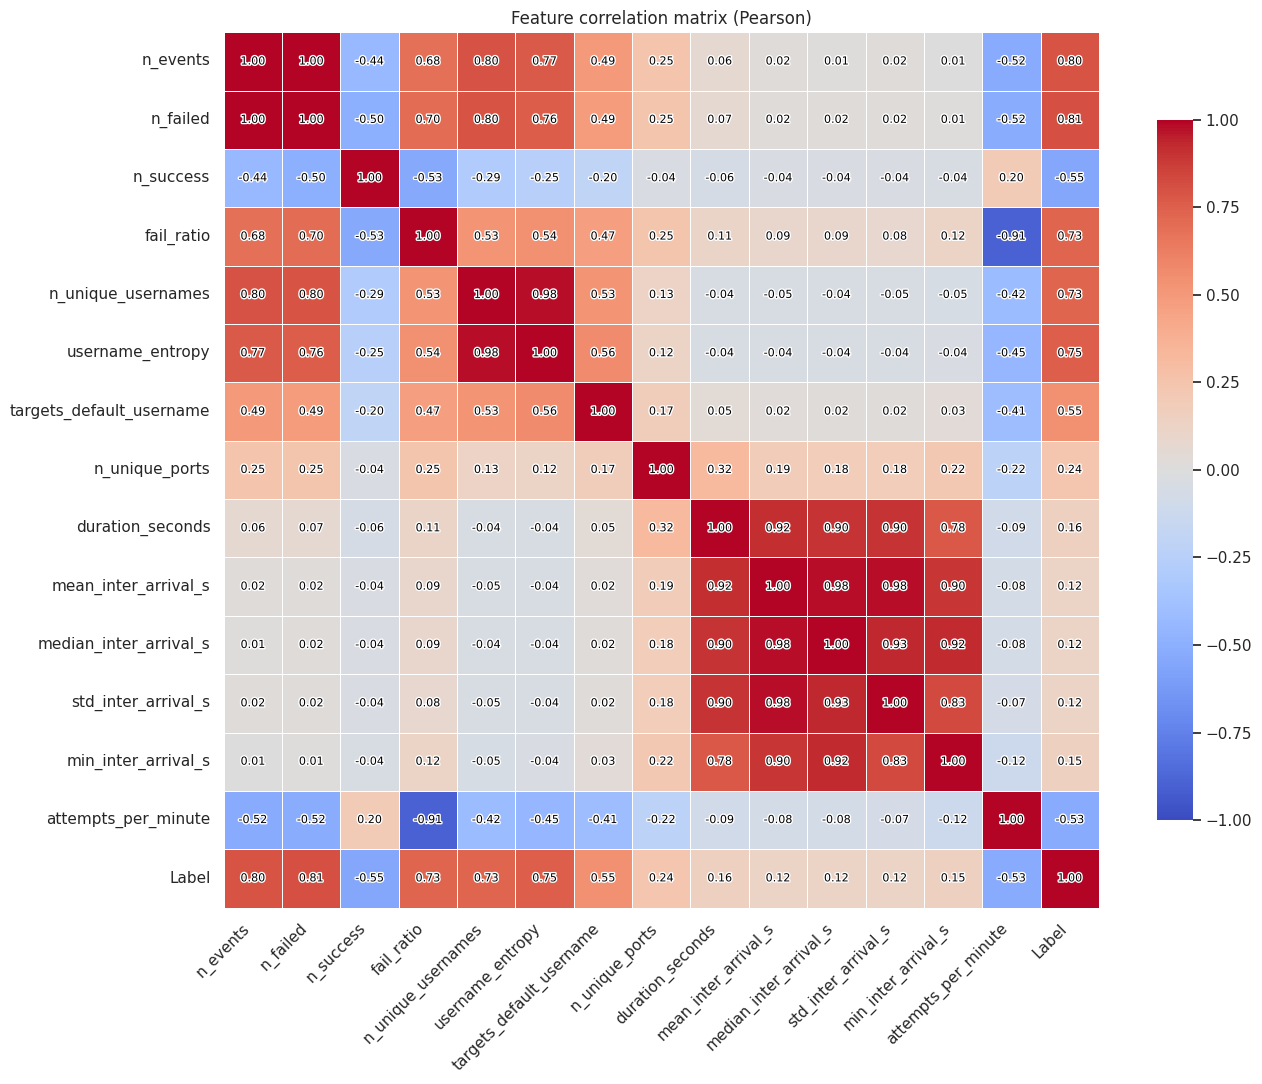

In [5]:
corr = features[FEATURE_COLS + ["Label"]].corr()

plt.figure(figsize=(14, 11))
ax = sns.heatmap(
    corr, annot=False, cmap="coolwarm", center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
)
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        val = corr.iloc[i, j]
        t = ax.text(j + 0.5, i + 0.5, f"{val:.2f}", ha="center", va="center",
                    fontsize=8, color="black")
        t.set_path_effects([pe.withStroke(linewidth=2, foreground="white")])

plt.title("Feature correlation matrix (Pearson)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [6]:
pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack().rename("corr").reset_index()
)
pairs.columns = ["feature_1", "feature_2", "corr"]
high_corr = pairs[(pairs["corr"].abs() > 0.85) & (pairs["feature_1"] != "Label") & (pairs["feature_2"] != "Label")]
print("Highly correlated feature pairs (|r| > 0.85):")
high_corr.sort_values("corr", key=abs, ascending=False)


Highly correlated feature pairs (|r| > 0.85):


,feature_1,feature_2,corr
1,n_events,n_failed,0.997612
146,mean_inter_arrival_s,std_inter_arrival_s,0.983388
65,n_unique_usernames,username_entropy,0.982872
145,mean_inter_arrival_s,median_inter_arrival_s,0.980015
161,median_inter_arrival_s,std_inter_arrival_s,0.931607
162,median_inter_arrival_s,min_inter_arrival_s,0.924356
129,duration_seconds,mean_inter_arrival_s,0.917335
58,fail_ratio,attempts_per_minute,-0.905883
131,duration_seconds,std_inter_arrival_s,0.903698
130,duration_seconds,median_inter_arrival_s,0.898698


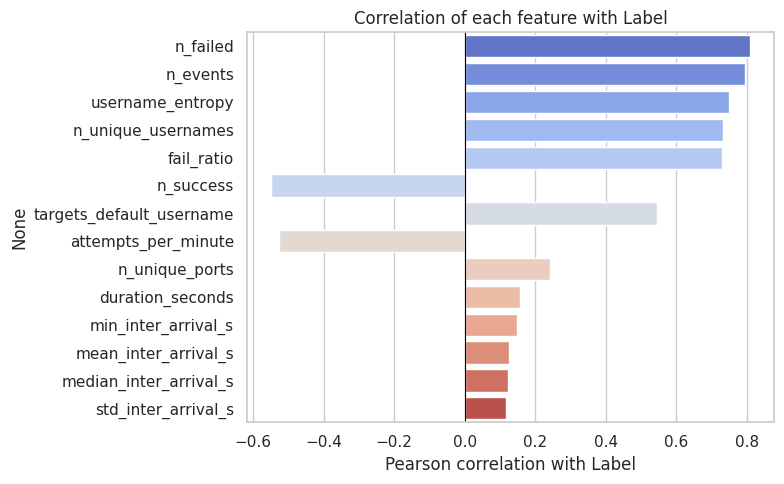

In [7]:
label_corr = corr["Label"].drop("Label").sort_values(key=abs, ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=label_corr.values, y=label_corr.index, palette="coolwarm")
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Correlation of each feature with Label")
plt.xlabel("Pearson correlation with Label")
plt.tight_layout()
plt.show()


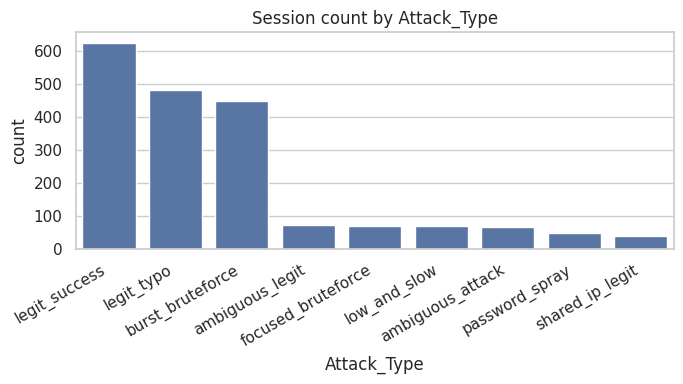

Attack_Type
legit_success         626
legit_typo            483
burst_bruteforce      450
ambiguous_legit        74
focused_bruteforce     70
low_and_slow           70
ambiguous_attack       66
password_spray         50
shared_ip_legit        40
Name: count, dtype: int64

In [8]:
plt.figure(figsize=(7, 4))
sns.countplot(data=features, x="Attack_Type", order=features["Attack_Type"].value_counts().index)
plt.xticks(rotation=30, ha="right")
plt.title("Session count by Attack_Type")
plt.tight_layout()
plt.show()
features["Attack_Type"].value_counts()


**New in v2 — check that overlap actually exists (not just claimed):**

In [9]:
for col in ["n_failed", "duration_seconds", "n_unique_usernames"]:
    print(f"\n=== {col} by Attack_Type ===")
    print(features.groupby("Attack_Type")[col].describe()[["min", "25%", "50%", "75%", "max"]].round(1))



=== n_failed by Attack_Type ===
                    min   25%   50%   75%   max
Attack_Type                                    
ambiguous_attack    2.0   4.0   6.0   9.0  12.0
ambiguous_legit     2.0   4.2   7.0   9.8  12.0
burst_bruteforce    5.0  15.2  25.0  33.0  40.0
focused_bruteforce  8.0  16.0  20.0  32.8  40.0
legit_success       0.0   0.0   0.0   0.0   0.0
legit_typo          1.0   1.0   2.0   4.0  10.0
low_and_slow        6.0  10.0  16.0  22.8  29.0
password_spray      4.0  12.2  21.0  26.8  56.0
shared_ip_legit     0.0   0.0   0.0   0.0   0.0

=== duration_seconds by Attack_Type ===
                      min     25%     50%      75%       max
Attack_Type                                                 
ambiguous_attack     20.6   164.4   282.2    382.3     609.6
ambiguous_legit      32.1   192.2   327.0    411.2     656.1
burst_bruteforce      7.1    17.6    24.9     31.5     637.0
focused_bruteforce    7.3    17.1    21.6     35.4      50.2
legit_success         0.0     0.

Look for genuine overlap between rows here — e.g. `legit_typo`'s max `n_failed` should reach into `focused_bruteforce`'s min, and `legit_typo`'s max `duration_seconds` should reach into `low_and_slow`'s min. If a model still separates these perfectly later, it's because it found a *combination* of features that works, not because the classes never touch on any single axis — which is the realistic version of this problem.

## 4. Train / test split

Stratified on `Attack_Type` so every pattern — including the now-larger but still smaller `focused_bruteforce`/`low_and_slow`/`password_spray`/`shared_ip_legit` classes — appears in both train and test.

In [10]:
X = features[FEATURE_COLS]
y = features["Label"]
attack_type = features["Attack_Type"]

X_train, X_test, y_train, y_test, at_train, at_test = train_test_split(
    X, y, attack_type, test_size=0.25, random_state=RANDOM_STATE, stratify=attack_type,
)
print("Train:", X_train.shape, " Test:", X_test.shape)
print("\nTest Attack_Type counts:\n", at_test.value_counts())


Train: (1446, 14)  Test: (483, 14)

Test Attack_Type counts:
 Attack_Type
legit_success         157
legit_typo            121
burst_bruteforce      113
ambiguous_legit        19
focused_bruteforce     18
low_and_slow           17
ambiguous_attack       16
password_spray         12
shared_ip_legit        10
Name: count, dtype: int64


## 5. Models

Same three as before (Logistic Regression baseline, Random Forest, XGBoost), same class-balancing, same 5-fold stratified CV scored on average precision (PR-AUC).

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    "logreg": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)),
    ]),
    "random_forest": RandomForestClassifier(
        n_estimators=300, max_depth=6, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "xgboost": XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.1,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        eval_metric="logloss", random_state=RANDOM_STATE,
    ),
}

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="average_precision")
    cv_results[name] = scores
    print(f"{name:15s} PR-AUC: {scores.mean():.4f} +/- {scores.std():.4f}")


logreg          PR-AUC: 0.9922 +/- 0.0032


random_forest   PR-AUC: 0.9938 +/- 0.0017


xgboost         PR-AUC: 0.9940 +/- 0.0023


In [12]:
for name, model in models.items():
    model.fit(X_train, y_train)
print("All models fit on the training set.")


All models fit on the training set.


## 6. Evaluation on the held-out test set

Same approach as v1: precision/recall/F1, ROC/PR-AUC, confusion matrix, and — the metric that matters most here — recall broken down **by `Attack_Type`**.

In [13]:
results_summary = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred, target_names=["legit", "attack"]))
    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    f1 = f1_score(y_test, y_pred)
    print(f"ROC-AUC: {roc_auc:.4f}   PR-AUC: {pr_auc:.4f}")
    results_summary.append({"model": name, "roc_auc": roc_auc, "pr_auc": pr_auc, "f1": f1})

results_summary = pd.DataFrame(results_summary).set_index("model")
results_summary



=== logreg ===
              precision    recall  f1-score   support

       legit       0.97      0.97      0.97       307
      attack       0.94      0.95      0.95       176

    accuracy                           0.96       483
   macro avg       0.96      0.96      0.96       483
weighted avg       0.96      0.96      0.96       483

ROC-AUC: 0.9946   PR-AUC: 0.9918

=== random_forest ===
              precision    recall  f1-score   support

       legit       0.98      0.96      0.97       307
      attack       0.93      0.96      0.94       176

    accuracy                           0.96       483
   macro avg       0.95      0.96      0.96       483
weighted avg       0.96      0.96      0.96       483

ROC-AUC: 0.9972   PR-AUC: 0.9953

=== xgboost ===
              precision    recall  f1-score   support

       legit       0.97      0.97      0.97       307
      attack       0.95      0.95      0.95       176

    accuracy                           0.97       483
   mac

,roc_auc,pr_auc,f1
model,,,
logreg,0.994577,0.991795,0.946176
random_forest,0.997224,0.995325,0.944134
xgboost,0.996743,0.994598,0.954545


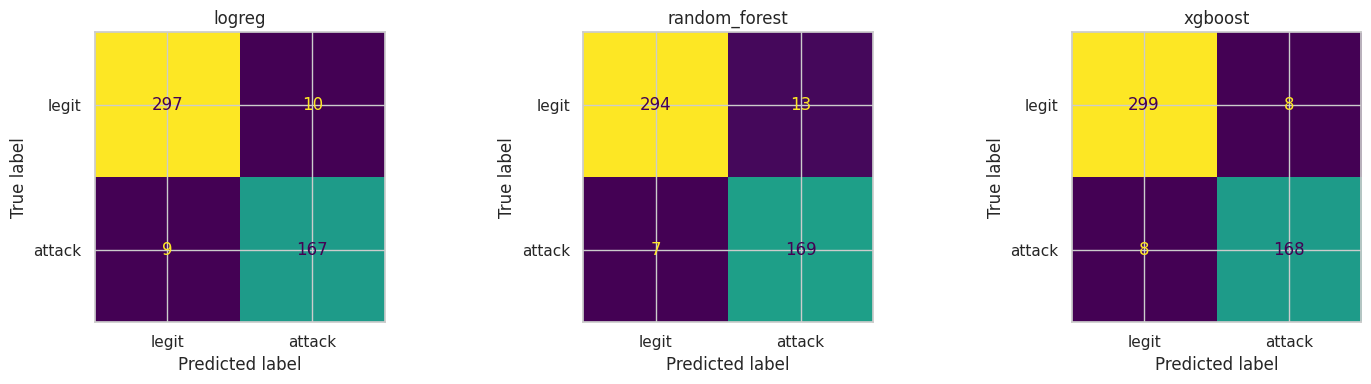

In [14]:
fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 4))
for ax, (name, model) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    ConfusionMatrixDisplay(cm, display_labels=["legit", "attack"]).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()


In [15]:
breakdown = []
for name, model in models.items():
    y_pred = pd.Series(model.predict(X_test), index=X_test.index)
    for atype in at_test.unique():
        mask = at_test == atype
        is_positive = features.loc[mask.index[mask], "Label"].iloc[0] if mask.any() else None
        if is_positive == 1:
            metric_name, value = "recall", y_pred[mask].mean()
        else:
            metric_name, value = "false_positive_rate", y_pred[mask].mean()
        breakdown.append({"model": name, "attack_type": atype, "n": mask.sum(), "metric": metric_name, "value": value})

breakdown_df = pd.DataFrame(breakdown).pivot_table(index=["attack_type", "n", "metric"], columns="model", values="value")
breakdown_df


,,model,logreg,random_forest,xgboost
attack_type,n,metric,,,
ambiguous_attack,16,recall,0.437500,0.562500,0.500000
ambiguous_legit,19,false_positive_rate,0.526316,0.631579,0.421053
burst_bruteforce,113,recall,1.000000,1.000000,1.000000
focused_bruteforce,18,recall,1.000000,1.000000,1.000000
legit_success,157,false_positive_rate,0.000000,0.000000,0.000000
legit_typo,121,false_positive_rate,0.000000,0.008264,0.000000
low_and_slow,17,recall,1.000000,1.000000,1.000000
password_spray,12,recall,1.000000,1.000000,1.000000
shared_ip_legit,10,false_positive_rate,0.000000,0.000000,0.000000


**Read this before the aggregate numbers.** With v1's disjoint parameter ranges every model hit 1.0 recall on every pattern, including 4-6-sample rare classes — a sign the dataset was trivially separable, not that detection was solved. Now that `legit_typo`/`focused_bruteforce`/`low_and_slow`/`shared_ip_legit`/`password_spray` genuinely overlap on at least one axis each, look here for whether any pattern's recall or false-positive-rate is now visibly less than perfect — that would be the *expected, healthier* outcome, not a regression. If everything is still exactly 1.0 even after the overlap introduced above, treat that as a prompt to add more overlap (blend the ranges further) rather than declaring success.

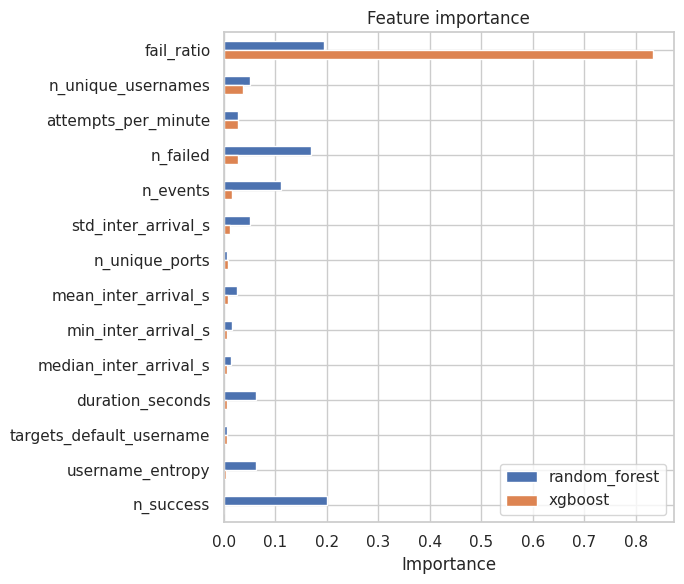

,random_forest,xgboost
fail_ratio,0.195403,0.832374
n_unique_usernames,0.051589,0.036639
attempts_per_minute,0.027294,0.028360
n_failed,0.170410,0.027272
n_events,0.110328,0.017040
std_inter_arrival_s,0.050815,0.012258
n_unique_ports,0.006090,0.007661
mean_inter_arrival_s,0.025437,0.007523
min_inter_arrival_s,0.016987,0.006480
median_inter_arrival_s,0.013955,0.006277


In [16]:
importances = pd.DataFrame({
    "random_forest": models["random_forest"].feature_importances_,
    "xgboost": models["xgboost"].feature_importances_,
}, index=FEATURE_COLS).sort_values("xgboost", ascending=False)

importances.plot(kind="barh", figsize=(7, 6))
plt.title("Feature importance")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
importances


## 7. Out-of-distribution generalization check

This is the check promised earlier: a completely separate set (`ssh_dataset_ood_v2.csv`), generated with a **different random seed and shifted parameter ranges** (e.g. a wider `low_and_slow` duration window), that no model here has seen in any form — not in training, not in cross-validation, not in threshold selection.

If performance holds up close to the held-out test set above, that's real evidence of generalization beyond this specific generator's habits. If it drops noticeably, that's the honest answer to "is this actually learning attacker behavior or the generator's fingerprint" — and it should drop somewhat; a large collapse means the model leaned on generator-specific quirks, a small one is the expected cost of any distribution shift.

In [17]:
ood_features = df_ood.groupby("Session_ID").apply(extract_session_features).reset_index()
X_ood = ood_features[FEATURE_COLS]
y_ood = ood_features["Label"]
at_ood = ood_features["Attack_Type"]

ood_summary = []
for name, model in models.items():
    y_pred = model.predict(X_ood)
    y_proba = model.predict_proba(X_ood)[:, 1]
    roc_auc = roc_auc_score(y_ood, y_proba)
    pr_auc = average_precision_score(y_ood, y_proba)
    f1 = f1_score(y_ood, y_pred)
    ood_summary.append({"model": name, "roc_auc": roc_auc, "pr_auc": pr_auc, "f1": f1})

ood_summary = pd.DataFrame(ood_summary).set_index("model")
print("Held-out TEST (same distribution as training):")
display(results_summary)
print("\nOOD set (different seed + shifted parameter ranges):")
display(ood_summary)
print("\nDrop (test - OOD):")
display(results_summary - ood_summary)


Held-out TEST (same distribution as training):


,roc_auc,pr_auc,f1
model,,,
logreg,0.994577,0.991795,0.946176
random_forest,0.997224,0.995325,0.944134
xgboost,0.996743,0.994598,0.954545



OOD set (different seed + shifted parameter ranges):


,roc_auc,pr_auc,f1
model,,,
logreg,0.999217,0.998567,0.982617
random_forest,0.999693,0.999379,0.981818
xgboost,0.999585,0.999166,0.979779



Drop (test - OOD):


,roc_auc,pr_auc,f1
model,,,
logreg,-0.004640,-0.006772,-0.036441
random_forest,-0.002469,-0.004054,-0.037684
xgboost,-0.002843,-0.004568,-0.025234


In [18]:
ood_breakdown = []
for name, model in models.items():
    y_pred = pd.Series(model.predict(X_ood), index=X_ood.index)
    for atype in at_ood.unique():
        mask = at_ood == atype
        is_positive = ood_features.loc[mask.index[mask], "Label"].iloc[0] if mask.any() else None
        if is_positive == 1:
            metric_name, value = "recall", y_pred[mask].mean()
        else:
            metric_name, value = "false_positive_rate", y_pred[mask].mean()
        ood_breakdown.append({"model": name, "attack_type": atype, "n": mask.sum(), "metric": metric_name, "value": value})

pd.DataFrame(ood_breakdown).pivot_table(index=["attack_type", "n", "metric"], columns="model", values="value")


,,model,logreg,random_forest,xgboost
attack_type,n,metric,,,
ambiguous_attack,22,recall,0.772727,0.909091,0.590909
ambiguous_legit,28,false_positive_rate,0.464286,0.642857,0.464286
burst_bruteforce,450,recall,1.000000,1.000000,1.000000
focused_bruteforce,25,recall,1.000000,1.000000,1.000000
legit_success,626,false_positive_rate,0.000000,0.000000,0.000000
legit_typo,443,false_positive_rate,0.000000,0.000000,0.000000
low_and_slow,25,recall,1.000000,1.000000,1.000000
password_spray,20,recall,1.000000,1.000000,1.000000
shared_ip_legit,15,false_positive_rate,0.066667,0.000000,0.000000


## 8. Threshold tuning

Same rationale as before: in a SOC context, missing an attack (false negative) is usually worse than flagging a legit session for review, so the default 0.5 cutoff is worth revisiting deliberately via the precision-recall curve rather than left at the default.

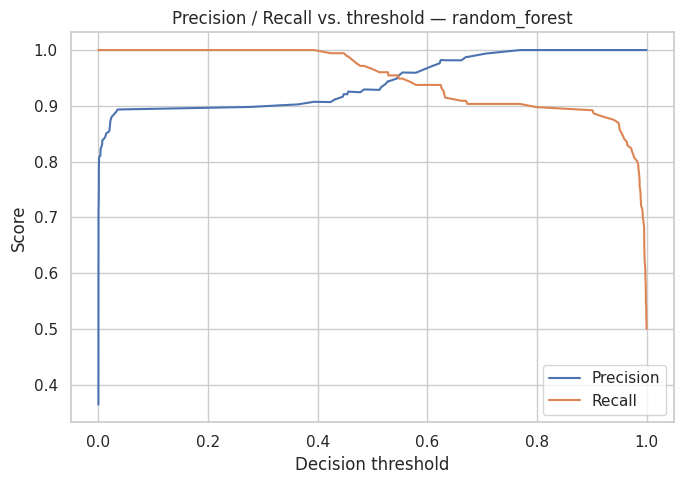

Threshold for recall >= 0.95: 0.547 (precision at that point: 0.955)


In [19]:
best_name = results_summary["pr_auc"].idxmax()
best_model = models[best_name]
y_proba = best_model.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.title(f"Precision / Recall vs. threshold — {best_name}")
plt.legend()
plt.tight_layout()
plt.show()

target_recall = 0.95
candidates = [(t, p) for t, r, p in zip(thresholds, recall[:-1], precision[:-1]) if r >= target_recall]
if candidates:
    chosen_threshold, chosen_precision = candidates[-1]
    print(f"Threshold for recall >= {target_recall}: {chosen_threshold:.3f} (precision at that point: {chosen_precision:.3f})")
else:
    print(f"No threshold in range reaches recall >= {target_recall} on this test set.")


## 9. Save the model artifact

In [20]:
joblib.dump(
    {"model": best_model, "feature_columns": FEATURE_COLS, "model_name": best_name},
    "ssh_bruteforce_model_v2.joblib",
)
print(f"Saved: ssh_bruteforce_model_v2.joblib (best model: {best_name})")


Saved: ssh_bruteforce_model_v2.joblib (best model: random_forest)


## What's still not covered here

- Production session-segmentation rule (time-gap per `Source_IP`) for a freshly uploaded, unlabeled log
- Wrapping model + feature extraction into an inference pipeline / API
- Real (e.g. honeypot) attack traffic — this is still entirely synthetic data; the OOD check above tests robustness to *this generator's* distribution shift, not to real-world attacker behavior
